In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


### Read File

In [2]:
train = pd.read_csv("/kaggle/input/spaceship-titanic/train.csv")
test = pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")
submission = pd.read_csv("/kaggle/input/spaceship-titanic/sample_submission.csv")

In [3]:
train

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [4]:
test

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


In [5]:
submission

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False
...,...,...
4272,9266_02,False
4273,9269_01,False
4274,9271_01,False
4275,9273_01,False


### Analyse train

In [6]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [7]:
train1 = train.dropna()
train1

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


### Analyse target

In [8]:
train1['Transported'].replace({False: 0, True: 1},inplace=True)
train1['Transported']

/opt/conda/lib/python3.7/site-packages/pandas/core/generic.py:6619: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


0       0
1       1
2       0
3       0
4       1
       ..
8688    0
8689    0
8690    1
8691    0
8692    1
Name: Transported, Length: 6606, dtype: int64

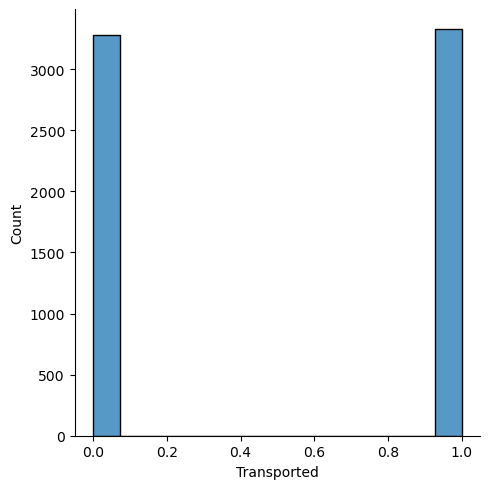

In [9]:
sns.displot(train1['Transported'])

In [10]:
trans_count = train1['Transported'].value_counts()
trans_count

1    3327
0    3279
Name: Transported, dtype: int64

In [11]:
trans_percent = trans_count / len(train1)
trans_percent

1    0.503633
0    0.496367
Name: Transported, dtype: float64

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  This is separate from the ipykernel package so we can avoid doing imports until
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  after removing the cwd from sys.path.


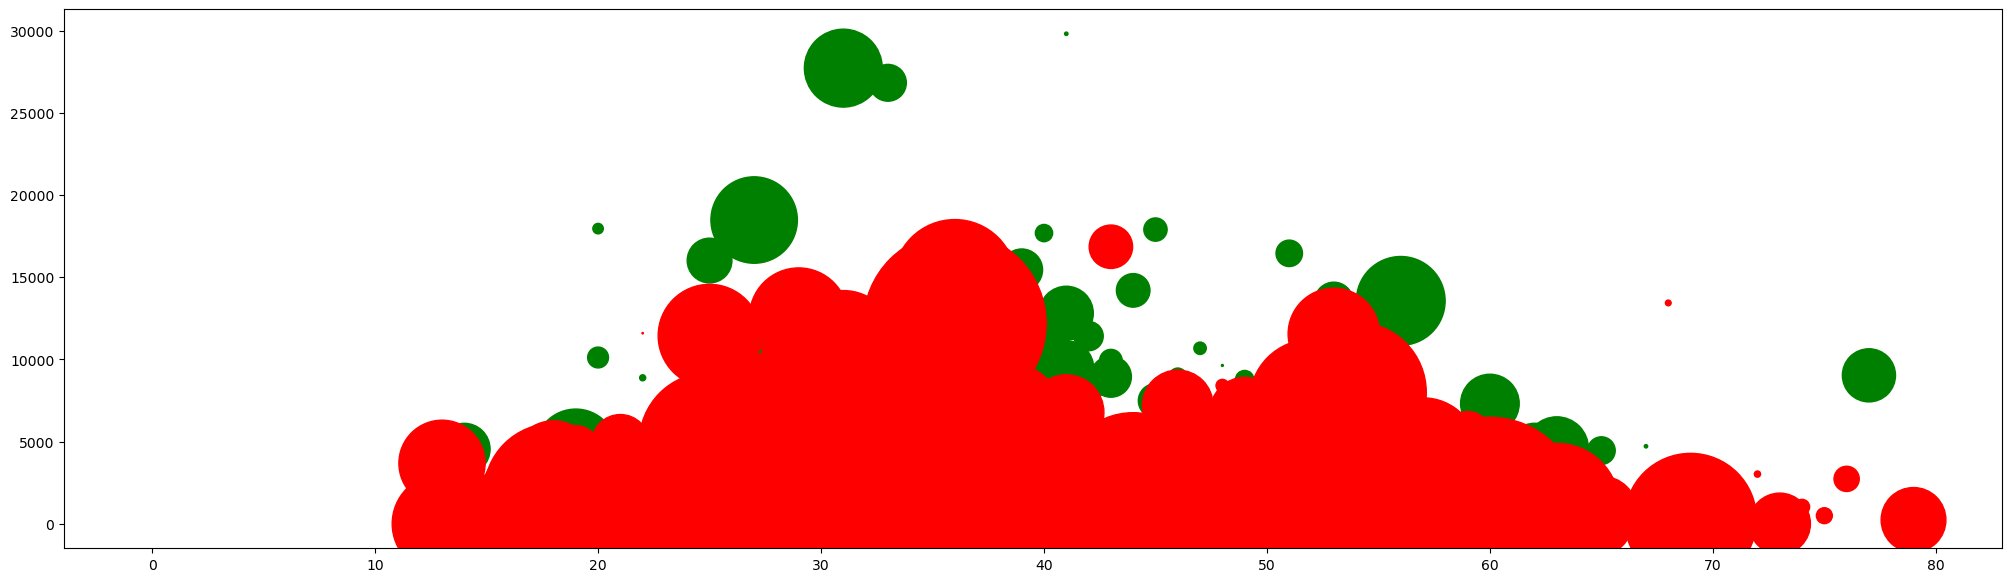

In [12]:
plt.figure(figsize=(25, 7))
ax = plt.subplot()
ax.scatter(train1[train1['Transported'] == 1]['Age'], train1[train['Transported'] == 1]['FoodCourt'], c='green', s=train1[train1['Transported'] == 1]['VRDeck'])
ax.scatter(train1[train1['Transported'] == 0]['Age'], train1[train['Transported'] == 0]['FoodCourt'], c='red', s=train1[train1['Transported'] == 0]['VRDeck'])

### Drop target

In [13]:
target = train1['Transported']

train1.drop(['Transported'],axis=1, inplace=True)
train1

/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre


### Combine train and test

In [14]:
combi = train1.append(test)
combi

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


### Analyse combi

In [15]:
combi.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10883 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   10883 non-null  object 
 1   HomePlanet    10796 non-null  object 
 2   CryoSleep     10790 non-null  object 
 3   Cabin         10783 non-null  object 
 4   Destination   10791 non-null  object 
 5   Age           10792 non-null  float64
 6   VIP           10790 non-null  object 
 7   RoomService   10801 non-null  float64
 8   FoodCourt     10777 non-null  float64
 9   ShoppingMall  10785 non-null  float64
 10  Spa           10782 non-null  float64
 11  VRDeck        10803 non-null  float64
 12  Name          10789 non-null  object 
dtypes: float64(6), object(7)
memory usage: 1.2+ MB


In [16]:
combi.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,10792.000000,10801.000000,10777.000000,10785.000000,10782.000000,10803.000000
mean,28.802539,221.544764,463.680894,177.945387,309.246151,306.472369
std,14.396816,630.484127,1621.887223,570.343750,1133.658617,1175.106100
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,51.000000,81.000000,31.000000,59.000000,44.000000
max,79.000000,11567.000000,29813.000000,12253.000000,22408.000000,22272.000000


### Check for null value

In [17]:
combi.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

### Impute null values

In [18]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer(random_state=42)

date = pd.Timestamp('2200-01-01')

for col in combi:
    if combi[col].dtype=="object":
        combi[col].fillna("not listed", inplace=True)
    if combi[col].dtype=="int":
        #X[col].fillna(X[col].mode()[0], inplace=True)
        combi[col].fillna(combi[col].mean(), inplace=True)
        #combi[col] = combi[col].astype.int()
    if combi[col].dtype=='float':
        #X[col].fillna(X[col].mean(), inplce=True)
        combi[col] = imp.fit_transform(combi[col].values.reshape(-1,1))
    if combi[col].dtype=="datetime64[ns]":
        combi[col].fillna(date, inplace=True)
combi

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.000000,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.000000,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.000000,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.000000,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.000000,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.000000,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,not listed,TRAPPIST-1e,42.000000,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,28.802539,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,not listed,28.802539,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


In [19]:
combi.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
dtype: int64

### Analyse feature

### Home Planet

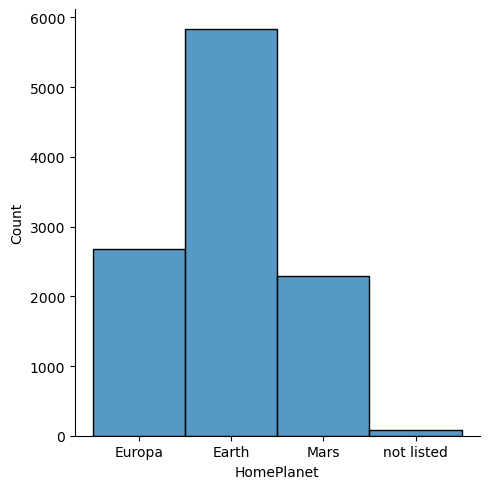

In [20]:
sns.displot(combi['HomePlanet'])


In [21]:
home_count = combi['HomePlanet'].value_counts()
home_count

Earth         5829
Europa        2675
Mars          2292
not listed      87
Name: HomePlanet, dtype: int64

In [22]:
home_percent = home_count / len(combi)
home_percent

Earth         0.535606
Europa        0.245796
Mars          0.210604
not listed    0.007994
Name: HomePlanet, dtype: float64

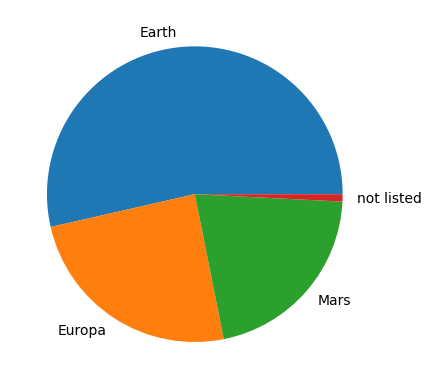

In [23]:
mylabels = ["Earth", "Europa", "Mars", "not listed"]
plt.pie(home_percent, labels=mylabels)
plt.show()

In [24]:
combi['HomePlanet'].replace({"Earth": 2, "Europa": 2, "Mars": 3, "not listed": 4},inplace=True)
combi['HomePlanet']

0       2
1       2
2       2
3       2
4       2
       ..
4272    2
4273    2
4274    3
4275    2
4276    2
Name: HomePlanet, Length: 10883, dtype: int64

In [25]:
combi['CryoSleep'][combi['CryoSleep']== 'not listed'] = False

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [26]:
print(combi.iloc[6674])

PassengerId         0156_01
HomePlanet                3
CryoSleep             False
Cabin                F/34/P
Destination     TRAPPIST-1e
Age               28.802539
VIP                   False
RoomService             0.0
FoodCourt               0.0
ShoppingMall            0.0
Spa                     0.0
VRDeck                  0.0
Name            Tures Upead
Name: 68, dtype: object


In [27]:
combi['CryoSleep'].replace({False: 0, True: 1})

0       0
1       0
2       0
3       0
4       0
       ..
4272    1
4273    0
4274    1
4275    0
4276    1
Name: CryoSleep, Length: 10883, dtype: int64

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  """Entry point for launching an IPython kernel.


<AxesSubplot:xlabel='CryoSleep', ylabel='Density'>

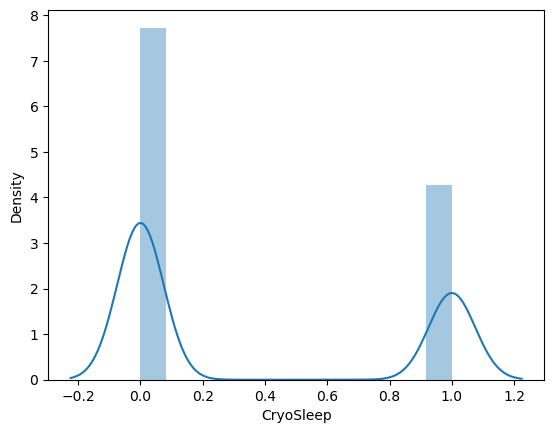

In [28]:
sns.distplot(combi['CryoSleep'])

In [29]:
sleep_count = combi['CryoSleep'].value_counts()
sleep_count

False    7007
True     3876
Name: CryoSleep, dtype: int64

In [30]:
sleep_percent = sleep_count / len(combi)
sleep_percent

False    0.643848
True     0.356152
Name: CryoSleep, dtype: float64

In [31]:
combi['CryoSleep'] = combi['CryoSleep'].astype(int)
combi['CryoSleep']

0       0
1       0
2       0
3       0
4       0
       ..
4272    1
4273    0
4274    1
4275    0
4276    1
Name: CryoSleep, Length: 10883, dtype: int64

### Destination

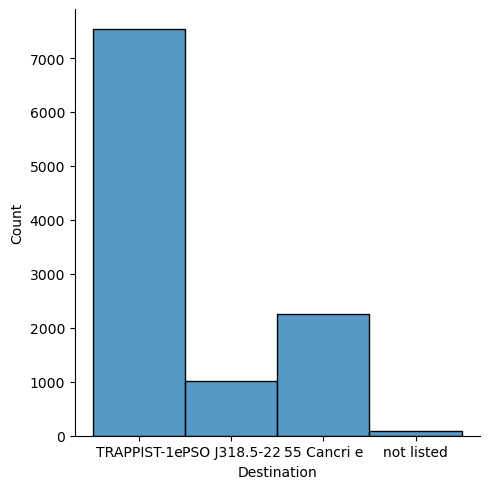

In [32]:
sns.displot(combi['Destination'])

In [33]:
dest_count = combi['Destination'].value_counts()
dest_count

TRAPPIST-1e      7532
55 Cancri e      2248
PSO J318.5-22    1011
not listed         92
Name: Destination, dtype: int64

In [34]:
dest_percent = dest_count / len(combi)
dest_percent

TRAPPIST-1e      0.692089
55 Cancri e      0.206561
PSO J318.5-22    0.092897
not listed       0.008454
Name: Destination, dtype: float64

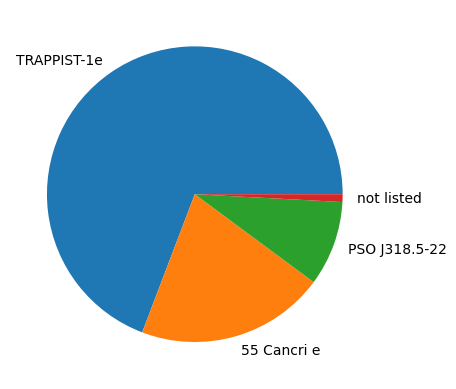

In [35]:
mylabels = ["TRAPPIST-1e", "55 Cancri e", "PSO J318.5-22", "not listed"]
plt.pie(dest_percent, labels=mylabels)
plt.show()

In [36]:
combi['Destination'].replace({"TRAPPIST-1e": 1,"55 Cancri e": 2, "PSO J318.5-22": 3, "not listed": 4},inplace=True)
combi['Destination']

0       1
1       1
2       1
3       1
4       1
       ..
4272    1
4273    1
4274    2
4275    4
4276    3
Name: Destination, Length: 10883, dtype: int64

### Age

In [37]:
combi['Age_group'] = pd.cut(x=combi['Age'], bins=[-1, 18, 40, 65, 100], labels=['child', 'young adult', 'middle age', 'pensioner'])
combi['Age_group']

0       young adult
1       young adult
2        middle age
3       young adult
4             child
           ...     
4272    young adult
4273     middle age
4274    young adult
4275    young adult
4276     middle age
Name: Age_group, Length: 10883, dtype: category
Categories (4, object): ['child' < 'young adult' < 'middle age' < 'pensioner']

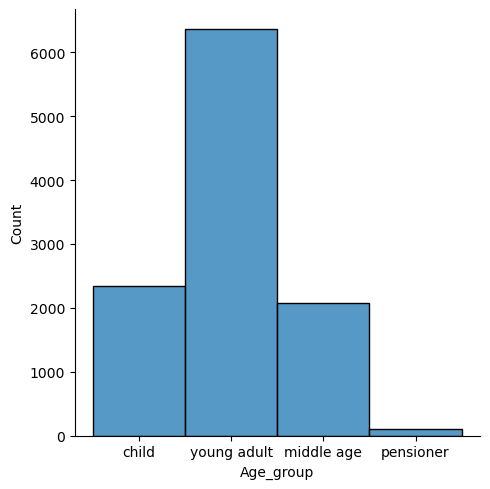

In [38]:
sns.displot(combi['Age_group'])

In [39]:
age_count = combi['Age_group'].value_counts()
age_count

young adult    6359
child          2340
middle age     2074
pensioner       110
Name: Age_group, dtype: int64

In [40]:
age_percent = age_count / len(combi)
age_percent

young adult    0.584306
child          0.215014
middle age     0.190572
pensioner      0.010108
Name: Age_group, dtype: float64

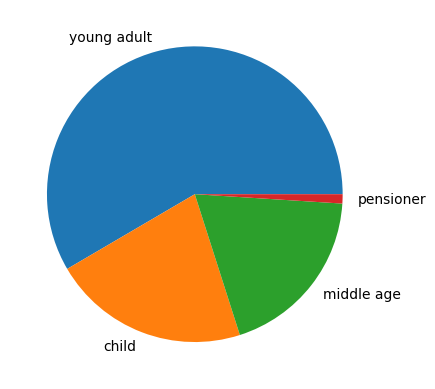

In [41]:
mylabels = ["young adult", "child", "middle age", "pensioner"]
plt.pie(age_percent, labels=mylabels)
plt.show()

In [42]:
combi['Age_group'].replace({"young adult": 1, "child": 2, "middle age": 3, "pensioner": 4},inplace=True)
combi['Age_group']

0       1
1       1
2       3
3       1
4       2
       ..
4272    1
4273    3
4274    1
4275    1
4276    3
Name: Age_group, Length: 10883, dtype: int64

In [43]:
combi['Age_group'] = combi['Age_group'].astype(int)

### VIP

In [44]:
combi['VIP'][combi['VIP'] == 'not listed'] = False

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [45]:
combi['VIP'].replace({False: 0, True: 1})

0       0
1       0
2       1
3       0
4       0
       ..
4272    0
4273    0
4274    0
4275    0
4276    0
Name: VIP, Length: 10883, dtype: int64

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  """Entry point for launching an IPython kernel.


<AxesSubplot:xlabel='VIP', ylabel='Density'>

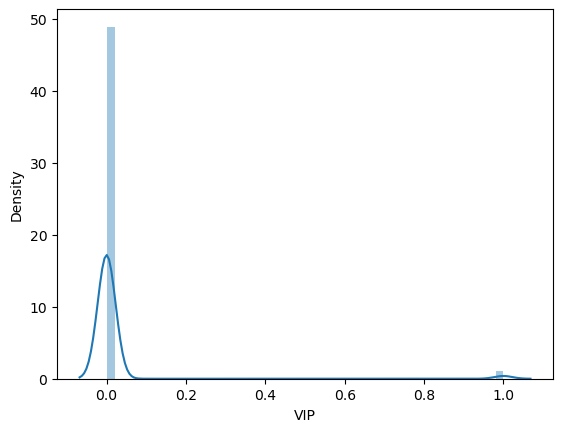

In [46]:
sns.distplot(combi['VIP'])

In [47]:
vip_count = combi['VIP'].value_counts()
vip_count

False    10647
True       236
Name: VIP, dtype: int64

In [48]:
vip_percent = vip_count / len(combi)
vip_percent

False    0.978315
True     0.021685
Name: VIP, dtype: float64

In [49]:
combi['VIP'] = combi['VIP'].astype(int)
combi['VIP']

0       0
1       0
2       1
3       0
4       0
       ..
4272    0
4273    0
4274    0
4275    0
4276    0
Name: VIP, Length: 10883, dtype: int64

### Room Service

<AxesSubplot:>

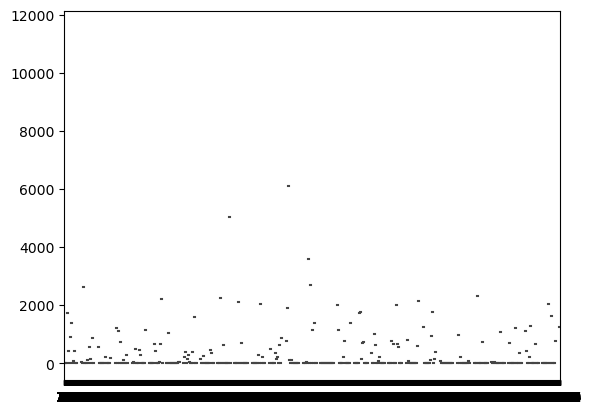

In [50]:
sns.violinplot(combi['RoomService'])

In [51]:
rm_service_high = combi['RoomService'].max()
print(rm_service_high)

11567.0


In [52]:
combi['Room_Service_group'] = pd.cut(x=combi['RoomService'], bins=[-1, 2000, 8000, 12000], labels=['low', 'med', 'high'])
combi['Room_Service_group']

0       low
1       low
2       low
3       low
4       low
       ... 
4272    low
4273    low
4274    low
4275    low
4276    low
Name: Room_Service_group, Length: 10883, dtype: category
Categories (3, object): ['low' < 'med' < 'high']

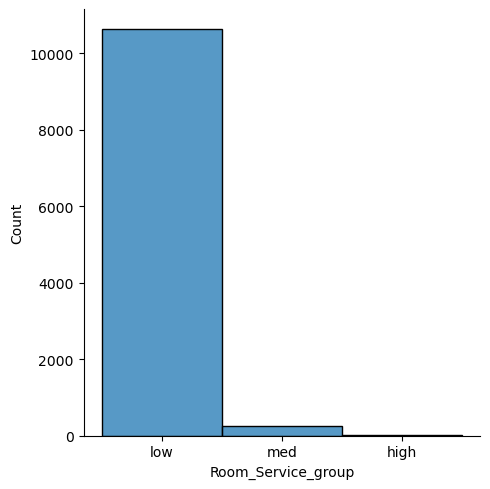

In [53]:
sns.displot(combi['Room_Service_group'])

In [54]:
rm_service_count = combi['Room_Service_group'].value_counts()
rm_service_count

low     10624
med       253
high        6
Name: Room_Service_group, dtype: int64

In [55]:
rm_service_percent = rm_service_count / len(combi)
rm_service_percent

low     0.976201
med     0.023247
high    0.000551
Name: Room_Service_group, dtype: float64

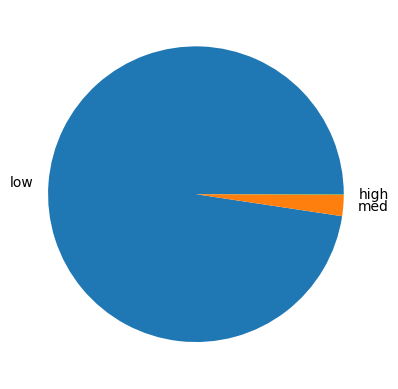

In [56]:
mylabels = ["low", "med", "high"]
plt.pie(rm_service_percent, labels=mylabels)
plt.show()

In [57]:
combi['Room_Service_group'].replace({"low": 1, "med": 2, "high": 3},inplace=True)
combi['Room_Service_group']

0       1
1       1
2       1
3       1
4       1
       ..
4272    1
4273    1
4274    1
4275    1
4276    1
Name: Room_Service_group, Length: 10883, dtype: int64

### Food Court

<AxesSubplot:>

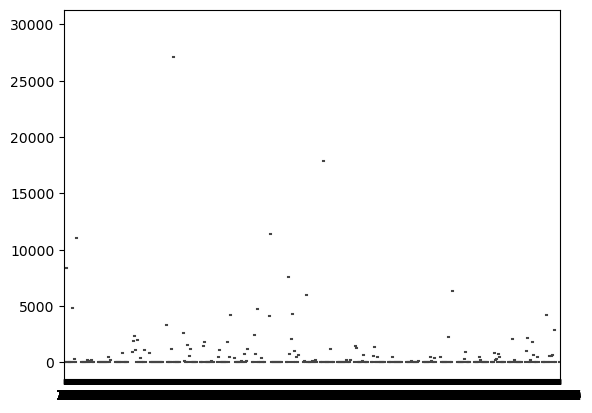

In [58]:
sns.violinplot(combi['FoodCourt'])

In [59]:
food_high = combi['FoodCourt'].max()
print(food_high)

29813.0


In [60]:
combi['Food_Court_group'] = pd.cut(x=combi['FoodCourt'], bins=[-1, 5000, 20000, 30000], labels=['low', 'med', 'high'])
combi['Food_Court_group']

0       low
1       low
2       low
3       low
4       low
       ... 
4272    low
4273    low
4274    low
4275    low
4276    low
Name: Food_Court_group, Length: 10883, dtype: category
Categories (3, object): ['low' < 'med' < 'high']

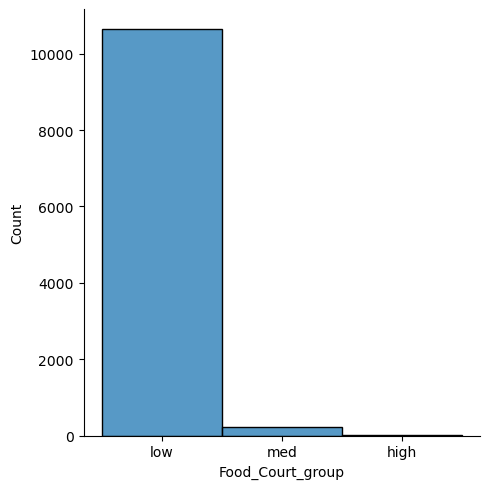

In [61]:
sns.displot(combi['Food_Court_group'])

In [62]:
fd_court_count = combi['Food_Court_group'].value_counts()
fd_court_count

low     10640
med       235
high        8
Name: Food_Court_group, dtype: int64

In [63]:
fd_court_percent = fd_court_count / len(combi)
fd_court_percent

low     0.977672
med     0.021593
high    0.000735
Name: Food_Court_group, dtype: float64

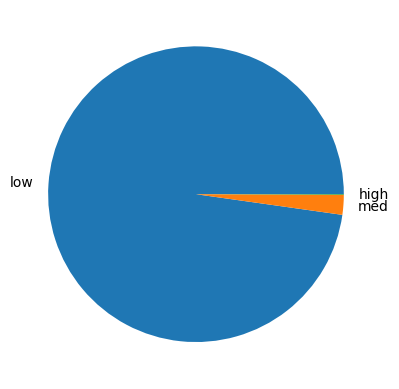

In [64]:
mylabels = ["low", "med", "high"]
plt.pie(fd_court_percent, labels=mylabels)
plt.show()

In [65]:
combi['Food_Court_group'].replace({"low": 1, "med": 2, "high": 3},inplace=True)
combi['Food_Court_group']

0       1
1       1
2       1
3       1
4       1
       ..
4272    1
4273    1
4274    1
4275    1
4276    1
Name: Food_Court_group, Length: 10883, dtype: int64

### Shopping Mall

<AxesSubplot:>

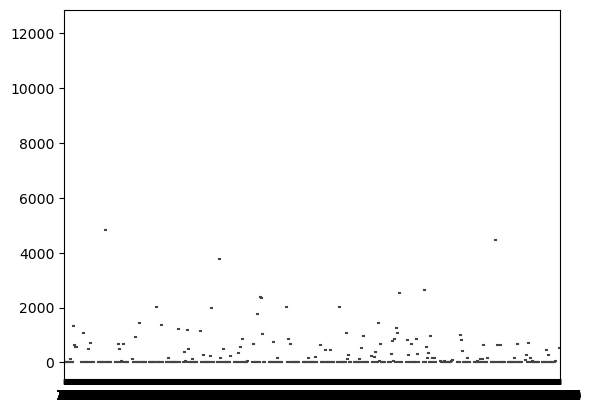

In [66]:
sns.violinplot(combi['ShoppingMall'])

In [67]:
shop_high = combi['ShoppingMall'].max()
print(shop_high)

12253.0


In [68]:
combi['Shopping_group'] = pd.cut(x=combi['ShoppingMall'], bins=[-1, 2000, 8000, 13000], labels=['low', 'med', 'high'])
combi['Shopping_group']

0       low
1       low
2       low
3       low
4       low
       ... 
4272    low
4273    low
4274    low
4275    low
4276    low
Name: Shopping_group, Length: 10883, dtype: category
Categories (3, object): ['low' < 'med' < 'high']

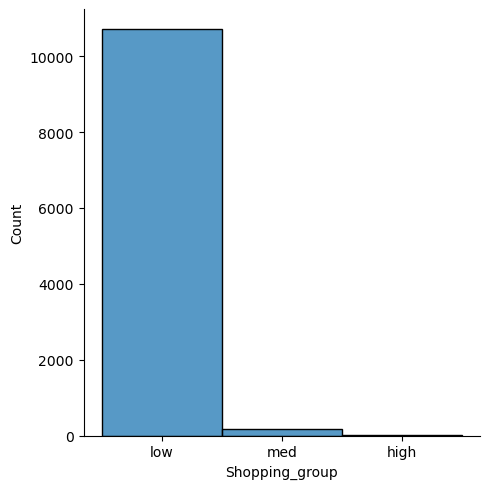

In [69]:
sns.displot(combi['Shopping_group'])

In [70]:
shopping_count = combi['Shopping_group'].value_counts()
shopping_count

low     10709
med       166
high        8
Name: Shopping_group, dtype: int64

In [71]:
shopping_percent = shopping_count / len(combi)
shopping_percent

low     0.984012
med     0.015253
high    0.000735
Name: Shopping_group, dtype: float64

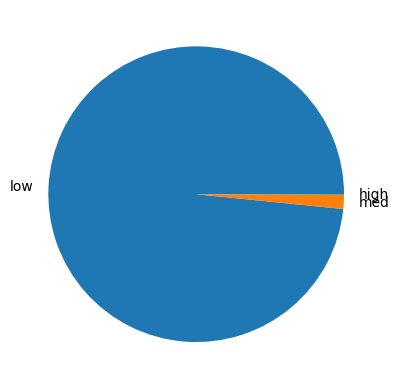

In [72]:
mylabels = ["low", "med", "high"]
plt.pie(shopping_percent, labels=mylabels)
plt.show()

In [73]:
combi['Shopping_group'].replace({"low": 1, "med": 2, "high": 3},inplace=True)
combi['Shopping_group']

0       1
1       1
2       1
3       1
4       1
       ..
4272    1
4273    1
4274    1
4275    1
4276    1
Name: Shopping_group, Length: 10883, dtype: int64

### Spa

<AxesSubplot:>

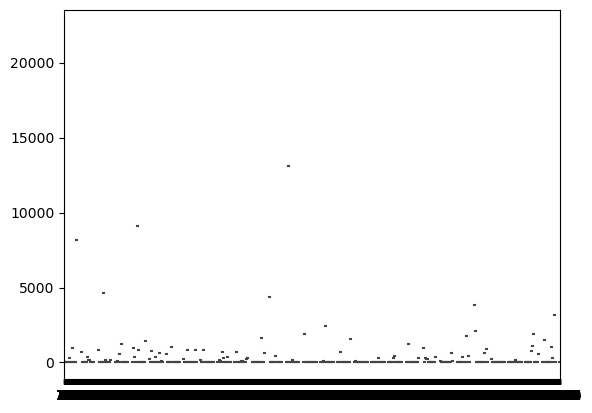

In [74]:
sns.violinplot(combi['Spa'])

In [75]:
spa_high = combi['Spa'].max()
print(spa_high)

22408.0


In [76]:
combi['Spa_group'] = pd.cut(x=combi['Spa'], bins=[-1, 5000, 15000, 23000], labels=['low', 'med', 'high'])
combi['Spa_group']

0       low
1       low
2       med
3       low
4       low
       ... 
4272    low
4273    low
4274    low
4275    low
4276    low
Name: Spa_group, Length: 10883, dtype: category
Categories (3, object): ['low' < 'med' < 'high']

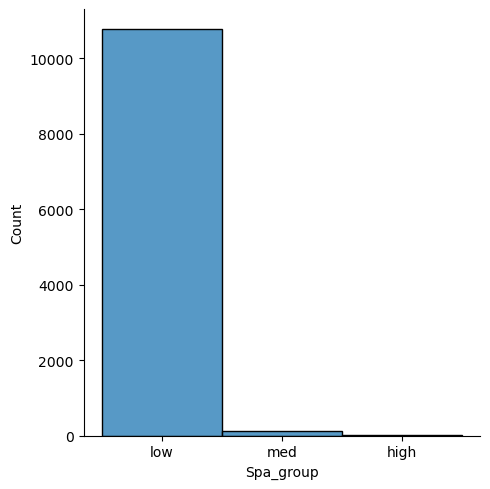

In [77]:
sns.displot(combi['Spa_group'])

In [78]:
spa_count = combi['Spa_group'].value_counts()
spa_count

low     10762
med       112
high        9
Name: Spa_group, dtype: int64

In [79]:
spa_percent = spa_count / len(combi)
spa_percent

low     0.988882
med     0.010291
high    0.000827
Name: Spa_group, dtype: float64

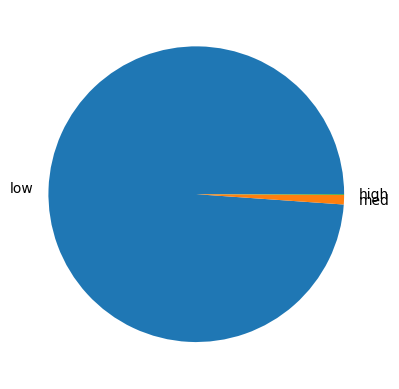

In [80]:
mylabels = ["low", "med", "high"]
plt.pie(spa_percent, labels=mylabels)
plt.show()

In [81]:
combi['Spa_group'].replace({"low": 1, "med": 2, "high": 3},inplace=True)
combi['Spa_group']

0       1
1       1
2       2
3       1
4       1
       ..
4272    1
4273    1
4274    1
4275    1
4276    1
Name: Spa_group, Length: 10883, dtype: int64

### VR Deck

<AxesSubplot:>

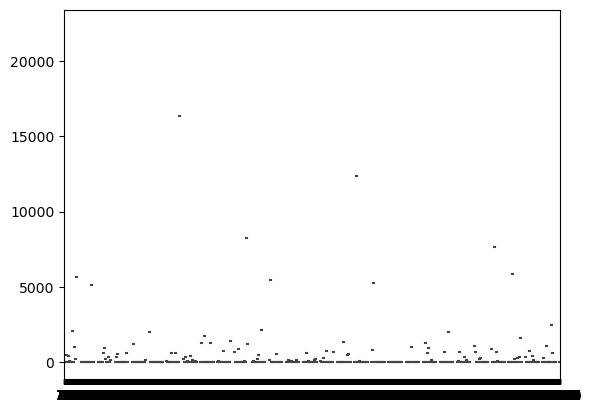

In [82]:
sns.violinplot(combi['VRDeck'])

In [83]:
vr_high = combi['VRDeck'].max()
print(vr_high)

22272.0


In [84]:
combi['VR_group'] = pd.cut(x=combi['VRDeck'], bins=[-1, 5000, 15000, 23000], labels=['low', 'med', 'high'])
combi['VR_group']

0       low
1       low
2       low
3       low
4       low
       ... 
4272    low
4273    low
4274    low
4275    low
4276    low
Name: VR_group, Length: 10883, dtype: category
Categories (3, object): ['low' < 'med' < 'high']

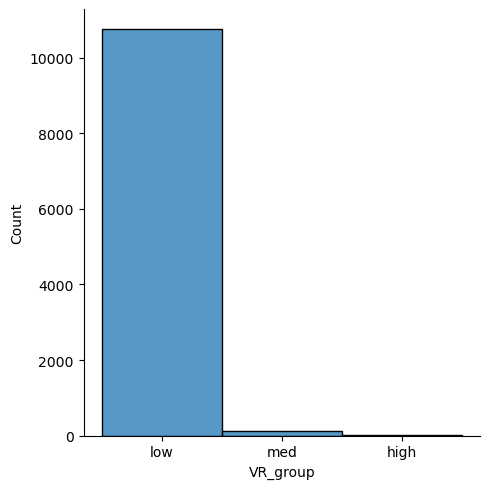

In [85]:
sns.displot(combi['VR_group'])

In [86]:
vr_count = combi['VR_group'].value_counts()
vr_count

low     10746
med       127
high       10
Name: VR_group, dtype: int64

In [87]:
vr_percent = vr_count / len(combi)
vr_percent

low     0.987412
med     0.011670
high    0.000919
Name: VR_group, dtype: float64

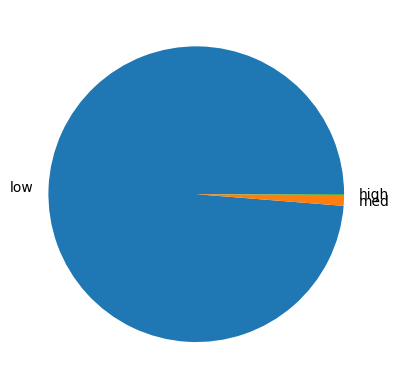

In [88]:
mylabel = ["low", "med", "high"]
plt.pie(vr_percent, labels=mylabels)
plt.show()

In [89]:
combi['VR_group'].replace({"low": 1, "med": 2, "high": 3},inplace=True)
combi['VR_group']

0       1
1       1
2       1
3       1
4       1
       ..
4272    1
4273    1
4274    1
4275    1
4276    1
Name: VR_group, Length: 10883, dtype: int64

### Assign features

In [90]:
combi.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10883 entries, 0 to 4276
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PassengerId         10883 non-null  object 
 1   HomePlanet          10883 non-null  int64  
 2   CryoSleep           10883 non-null  int64  
 3   Cabin               10883 non-null  object 
 4   Destination         10883 non-null  int64  
 5   Age                 10883 non-null  float64
 6   VIP                 10883 non-null  int64  
 7   RoomService         10883 non-null  float64
 8   FoodCourt           10883 non-null  float64
 9   ShoppingMall        10883 non-null  float64
 10  Spa                 10883 non-null  float64
 11  VRDeck              10883 non-null  float64
 12  Name                10883 non-null  object 
 13  Age_group           10883 non-null  int64  
 14  Room_Service_group  10883 non-null  int64  
 15  Food_Court_group    10883 non-null  int64  
 16  Shopp

### Define X and y

In [91]:
features = ["HomePlanet", "CryoSleep", "Destination", "Age_group", "Room_Service_group", "Food_Court_group", "Shopping_group", "Spa_group", "VR_group"]

y = target
X = combi[features][: len(train1)]
X_test = combi[features][len(train1) :]

### Heatmap

<AxesSubplot:>

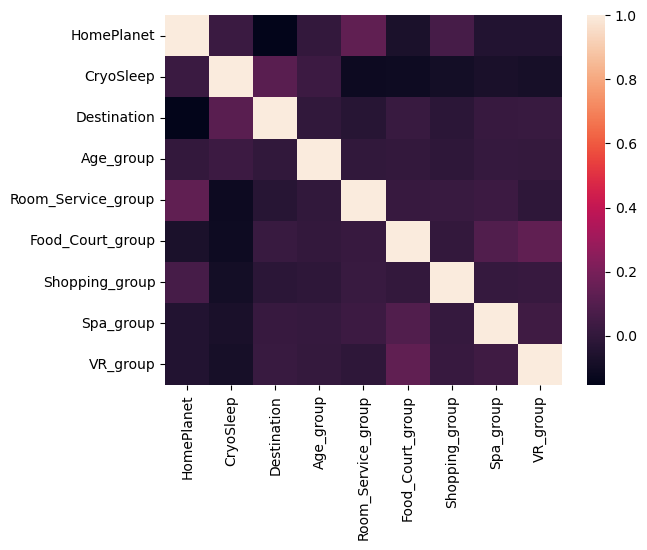

In [92]:
cmap = combi[features].corr()
sns.heatmap(cmap)

### Split dataset for training and validating

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.10, random_state=1, stratify=y, shuffle=True)
X_train.shape, X_val.shape, y_train.shape, y_val.shape, X_test.shape

((5945, 9), (661, 9), (5945,), (661,), (4277, 9))

### Select model

In [94]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, C=10).fit(X_train, y_train)
print(model.score(X_train, y_train))

0.7401177460050462


### Predict validation

In [95]:
y_pred = model.predict(X_val)
print(model.score(X_val, y_val))

0.7428139183055976


### Confusion matrix

In [96]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_val, y_pred))

[[292  36]
 [134 199]]


### Predict on X_test

In [97]:
predictions = model.predict(X_test)
predictions = predictions.astype(str)
predictions = np.char.replace(predictions, '0', 'False')
predictions = np.char.replace(predictions, '1', 'True')
predictions

array(['True', 'False', 'True', ..., 'True', 'False', 'True'], dtype='<U5')

### Prepare and submit

In [98]:
submission['Transported'] = predictions
submission.to_csv('submission.csv', index=False)
my_submission = pd.read_csv("submission.csv")
my_submission

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,False
